In [1]:
# PLOT WEIGHT VARIANCE ACROSS BOOTSTRAPS FOR RAW AND FITTED TRANSITION HIERARCHIES

import pickle
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from pathlib import Path

# ---------- Load records ----------
def load_records(pkl_path):
    records = []
    with open(pkl_path, "rb") as f:
        while True:
            try:
                records.append(pickle.load(f))
            except EOFError:
                break
    return records

# ---------- Helpers ----------
def stack_values(records, key):
    """
    Returns array of shape (n_bootstrap, 36) for all keys.
    For 'a_raw_count', each 36x1 is reshaped to 6x6, row-normalized, then flattened.
    """
    n_bootstrap = len(records)
    n_states = 6

    matrices = []
    for r in records:
        mat = np.asarray(r[key]).reshape(-1)  # flatten initially

        if key == "a_raw_count":
            mat = mat.reshape(n_states, n_states)          # 36 → 6x6
            row_sums = mat.sum(axis=1, keepdims=True)      # row sums
            mat = np.divide(mat, row_sums, where=row_sums != 0)  # row-normalize
            mat = mat.reshape(-1)                          # flatten back to 36

        matrices.append(mat)

    return np.stack(matrices)


def plot_value_drift(values, title):
    plt.figure(figsize=(6,6))
    n_steps = values.shape[0]
    
    n_lines = values.shape[1]
    colors = plt.cm.gist_ncar_r(np.linspace(0.05, 0.95, n_lines))

    labels = ["B", "DT", "C", "L", "PT", "R"]
    legend_labels = [f"from {r} to {c}" for r in labels for c in labels] 

    for i in range(values.shape[1]):
        plt.plot(values[:, i], alpha=0.4, color = colors[i])

        plt.text(n_steps-1,values[-1,i], legend_labels[i], fontsize=7, 
                 verticalalignment='center', horizontalalignment='left',
                 color=colors[i])
    
    plt.xlabel("Bootstrap")
    plt.ylabel("Weight")
    plt.title(title)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8, ncol=1)
    plt.tight_layout()
    plt.savefig(f"result/plots/{title}",format="svg")
    plt.show()


/var/folders/x_/3yztxnw56vg531g8c4w1xj1c0000gn/T/ipykernel_10927/1682111375.py:64: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8, ncol=1)


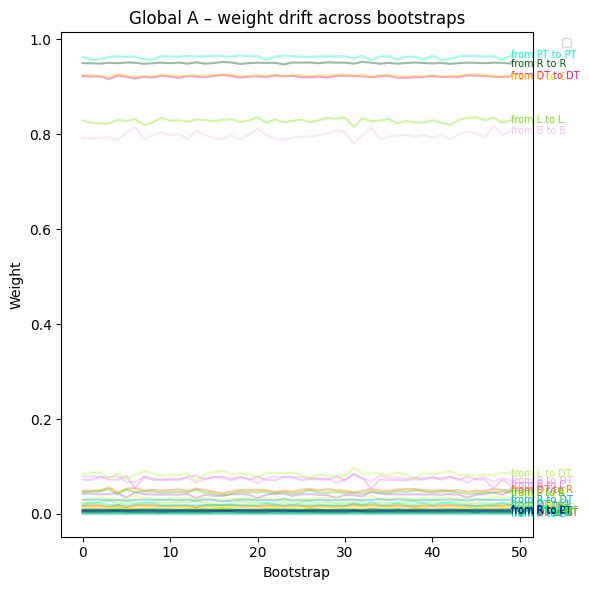

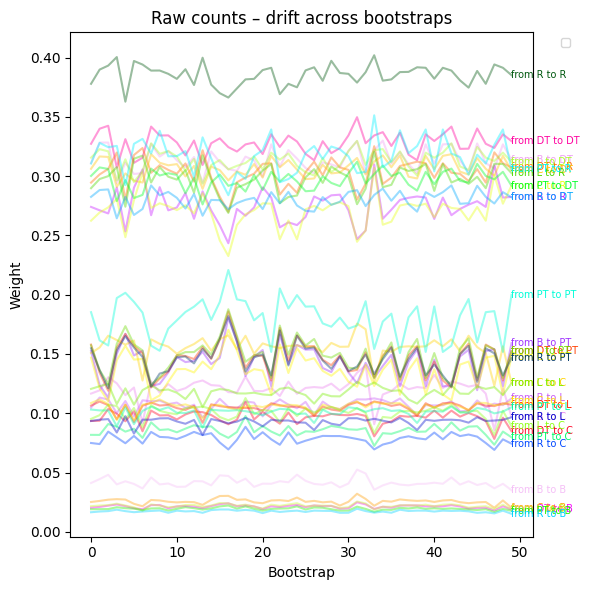

In [21]:
records = load_records("runs/bootstrap/results_mouse.pkl")
records = records[0:50]
assert len(records) == 50

# ---------- Global A ----------
A_vals = stack_values(records, "global_a")
plot_value_drift(A_vals, "Global A – weight drift across bootstraps")

# ---------- Raw counts ----------
raw_vals = stack_values(records, "a_raw_count")
plot_value_drift(raw_vals, "Raw counts – drift across bootstraps")

/var/folders/x_/3yztxnw56vg531g8c4w1xj1c0000gn/T/ipykernel_10927/1682111375.py:64: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8, ncol=1)


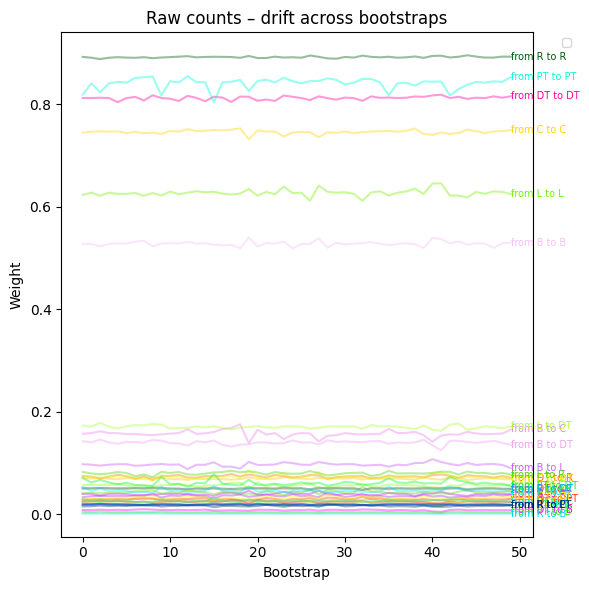

In [8]:
records = load_records("runs/bootstrap/results_a_raw_mouse.pkl")
assert len(records) == 50

# ---------- Raw counts ----------
raw_vals = stack_values(records, "a_raw_count")
plot_value_drift(raw_vals, "Raw counts – drift across bootstraps")

/var/folders/x_/3yztxnw56vg531g8c4w1xj1c0000gn/T/ipykernel_10927/1682111375.py:64: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8, ncol=1)


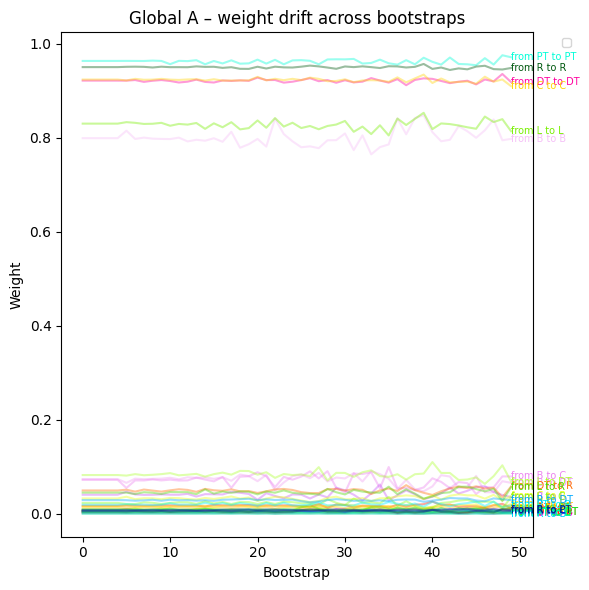

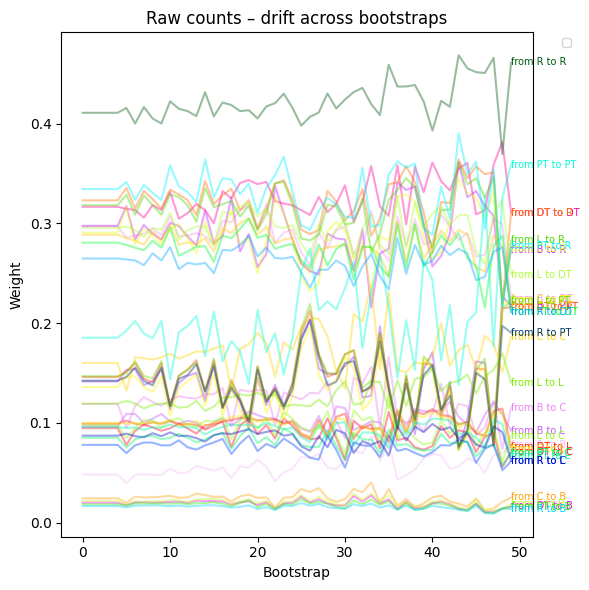

In [3]:
records = load_records("runs/bootstrap/results_shrink.pkl")
assert len(records) == 50

# ---------- Global A ----------
A_vals = stack_values(records, "global_a")
plot_value_drift(A_vals, "Global A – weight drift across bootstraps")

# ---------- Raw counts ----------
raw_vals = stack_values(records, "a_raw_count")
plot_value_drift(raw_vals, "Raw counts – drift across bootstraps")

/var/folders/x_/3yztxnw56vg531g8c4w1xj1c0000gn/T/ipykernel_10927/1682111375.py:64: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8, ncol=1)


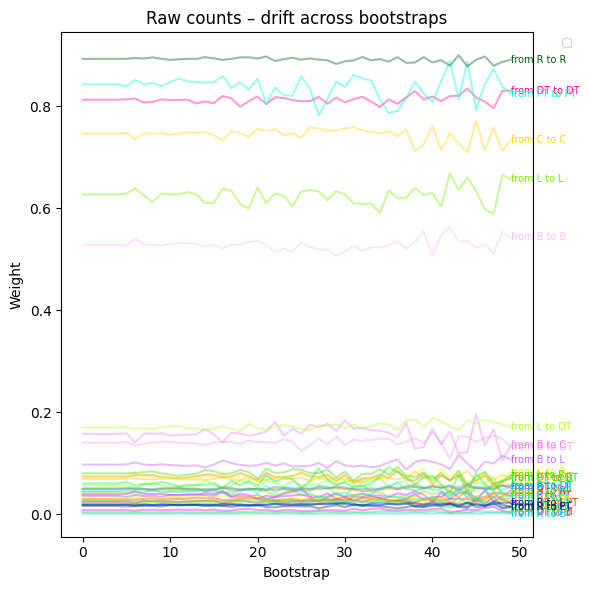

In [ ]:
records = load_records("runs/bootstrap/results_a_raw_shrink.pkl")
assert len(records) == 50

# ---------- Raw counts ----------
raw_vals = stack_values(records, "a_raw_count")
plot_value_drift(raw_vals, "Raw counts – drift across bootstraps")